# 🏙️ PropertyIQ: A 20-Minute Data Visualization Sprint
### Unit 1 — Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** [Melbourne Housing Snapshot](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) (Kaggle)

---

## 📖 The Scenario

You have just joined **PropertyIQ**, a Melbourne-based real-estate analytics startup, as a **junior data analyst**.

Tomorrow morning, your **Head of Sales** is meeting a client — a property investment fund — and needs a short briefing built from the `melb_data.csv` housing snapshot. She has given you **20 minutes** to turn the raw data into something she can actually present.

She says:

> *"I don't want a data dump. I want to walk in, show three good visuals, and leave the client with one clear takeaway. Make sure the charts are the right *type*, saved in the right *format*, and that the design doesn't get in the way of the message."*

This activity walks you through exactly the workflow described in the lecture: **understand the context → choose the right chart → choose the right file format → separate content from design → tell the story.**




## Part 0 — Setup (1 min)

1. Download **`melb_data.csv`** from the [Kaggle dataset page](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot).
2. Place it in the **same folder** as this notebook.
3. Run the cell below.

*(If the file isn't found, the cell will auto-generate a small synthetic stand-in with the same columns, so you can still complete the activity — just swap in the real CSV later.)*


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

DATA_PATH = "melb_data.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("melb_data.csv not found — generating a small synthetic stand-in so you can still run the activity.")
    n = 600
    regions = ["Northern Metropolitan", "Western Metropolitan", "Southern Metropolitan",
               "Eastern Metropolitan", "South-Eastern Metropolitan"]
    types = ["h", "u", "t"]  # house, unit, townhouse
    df = pd.DataFrame({
        "Suburb": np.random.choice(["Richmond", "Brunswick", "Carlton", "Footscray",
                                     "St Kilda", "Fitzroy", "Camberwell"], n),
        "Rooms": np.random.randint(1, 6, n),
        "Type": np.random.choice(types, n, p=[0.6, 0.3, 0.1]),
        "Price": np.random.lognormal(mean=13.5, sigma=0.4, size=n).round(-3),
        "Distance": np.round(np.random.exponential(8, n), 1),
        "Landsize": np.random.exponential(400, n).round(0),
        "BuildingArea": np.random.normal(150, 50, n).clip(30, 500).round(0),
        "YearBuilt": np.random.randint(1900, 2018, n),
        "Regionname": np.random.choice(regions, n),
        "Bathroom": np.random.randint(1, 4, n),
        "Car": np.random.randint(0, 4, n),
    })

df.head()


Loaded real dataset: 13580 rows, 20 columns


,Date,Suburb,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Price
0,23/09/2017,Aberfeldie,5,h,S,Rendina,7.5,3040,5,4,4.0,730,373.0,2014.0,NaN,-37.75950,144.89427,Western Metropolitan,1543,1830000
1,23/09/2017,Airport West,3,h,S,Brad,10.4,3042,3,1,2.0,551,96.0,1950.0,NaN,-37.72739,144.88235,Western Metropolitan,3464,850000
2,23/09/2017,Airport West,3,h,S,Harcourts,10.4,3042,3,2,2.0,593,NaN,NaN,NaN,-37.72057,144.87558,Western Metropolitan,3464,860000
3,23/09/2017,Albanvale,3,h,S,Bells,14.0,3021,3,1,2.0,619,NaN,NaN,NaN,-37.74521,144.76863,Western Metropolitan,1899,565000
4,23/09/2017,Albert Park,3,h,VB,Cayzer,3.0,3206,3,2,NaN,137,125.0,1890.0,NaN,-37.84388,144.95303,Southern Metropolitan,3280,2100000


## Part 1 — Understand the Context (3 min)

> *"Good data visualization begins with understanding the problem, not by choosing a chart."*

Recall the lecture's distinction:

| Exploratory Analysis | Explanatory Analysis |
|---|---|
| Explores data to discover patterns | Communicates a clear insight |
| Multiple hypotheses tested | One key message emphasized |
| Used by the analyst | Designed for the audience |

**Run the cell below** to get a quick feel for the data (this is *exploratory* — you're doing it for yourself, not the client).


In [10]:
df.info()
df.describe(include="all").T.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           13580 non-null  str    
 1   Suburb         13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Method         13580 non-null  str    
 5   SellerG        13580 non-null  str    
 6   Distance       13580 non-null  float64
 7   Postcode       13580 non-null  int64  
 8   Bedroom2       13580 non-null  int64  
 9   Bathroom       13580 non-null  int64  
 10  Car            13518 non-null  float64
 11  Landsize       13580 non-null  int64  
 12  BuildingArea   7130 non-null   float64
 13  YearBuilt      8205 non-null   float64
 14  CouncilArea    12211 non-null  str    
 15  Lattitude      13580 non-null  float64
 16  Longtitude     13580 non-null  float64
 17  Regionname     13580 non-null  str    
 18  Propertycount  13

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,13580,58,27/05/2017,473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Suburb,13580,314,Reservoir,359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rooms,13580.0,NaN,NaN,NaN,2.937997,0.955748,1.0,2.0,3.0,3.0,10.0
Type,13580,3,h,9449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method,13580,5,S,9022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SellerG,13580,268,Nelson,1565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance,13580.0,NaN,NaN,NaN,10.137776,5.868725,0.0,6.1,9.2,13.0,48.1
Postcode,13580.0,NaN,NaN,NaN,3105.301915,90.676964,3000.0,3044.0,3084.0,3148.0,3977.0
Bedroom2,13580.0,NaN,NaN,NaN,2.914728,0.965921,0.0,2.0,3.0,3.0,20.0
Bathroom,13580.0,NaN,NaN,NaN,1.534242,0.691712,0.0,1.0,1.0,2.0,8.0


### ✍️ Your turn (fill in the markdown cell below)

Answer in 1–2 sentences each:

1. **Who** is the audience for the visuals you're about to build (recall the scenario)?
2. Is the work you just did (`df.info()`, `df.describe()`) *exploratory* or *explanatory*? Why?
3. What is **one** question that the investment fund client would actually care about?


**Your answers:**

1. Audience: The audience is a property investment fund client interested in understanding the Melbourne housing market and identifying potential investment opportunities.
2. Exploratory or explanatory, and why: This analysis is exploratory because functions such as df.info() and df.describe() are used to examine the dataset, understand its structure, and identify key characteristics before drawing specific conclusions.
3. A question the client cares about: Which regions in Melbourne offer the most attractive property prices and investment opportunities?


## Part 2 — Choosing the Right Chart (7 min)

Recall the recommendation table from the lecture:

| Purpose | Recommended Chart |
|---|---|
| Compare categories | Bar Chart |
| Show trends | Line Chart |
| Show relationships | Scatter Plot |
| Show distributions | Histogram / Box Plot |
| Show proportions | Stacked Bar (limited categories) |

Your Head of Sales wants **three** visuals for the briefing. For each question below:
1. Write down which chart type is appropriate (and *why*, referencing the table).
2. Fill in the `# TODO` in the code to build it.

Avoid choosing a chart just because it "looks nice" — first identify what question it needs to answer.


### 2.1 — "How do average prices differ across regions?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:A bar chart is appropriate because the goal is to compare a numerical value (average price) across different categories (regions).**


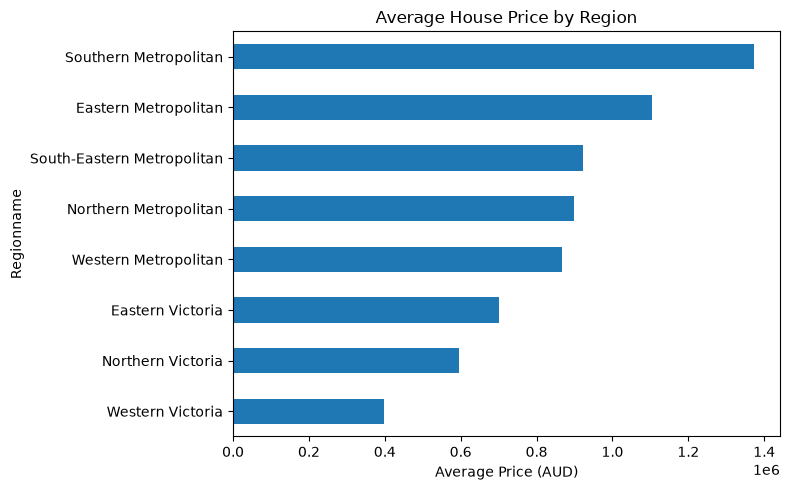

In [11]:
# TODO: Build a chart that compares average Price across Regionname
# Hint: group by Regionname, take the mean Price, then plot

region_avg = df.groupby("Regionname")["Price"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))

# TODO: replace the line below with the appropriate chart type
region_avg.plot(kind="barh", ax=ax)   # <-- fill in: "barh" or "bar" is a good fit here

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()
plt.show()


### 2.2 — "Is there a relationship between land size and price?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:A scatter plot is appropriate because the goal is to show the relationship between two numerical variables: land size and price.**


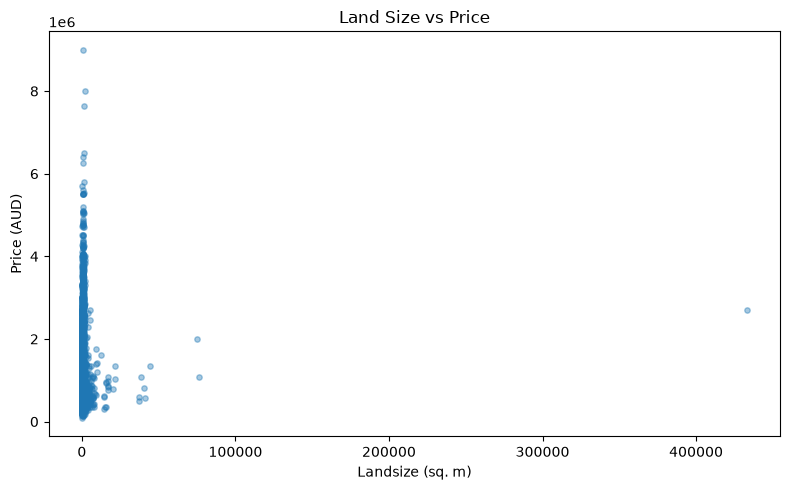

In [12]:
# TODO: Build a chart that shows the relationship between Landsize and Price

fig, ax = plt.subplots(figsize=(8, 5))

# TODO: fill in x, y, and the correct plotting function
ax.scatter(df["Landsize"], df["Price"], alpha=0.4, s=15)

ax.set_xlabel("Landsize (sq. m)")
ax.set_ylabel("Price (AUD)")
ax.set_title("Land Size vs Price")
plt.tight_layout()
plt.show()


### 2.3 — "What does the overall spread of prices in the market look like?"

**Chart type:** *(bar / line / scatter / histogram / stacked bar)* → your answer:

**Why:A histogram is appropriate because the goal is to show the overall distribution and spread of property prices.**


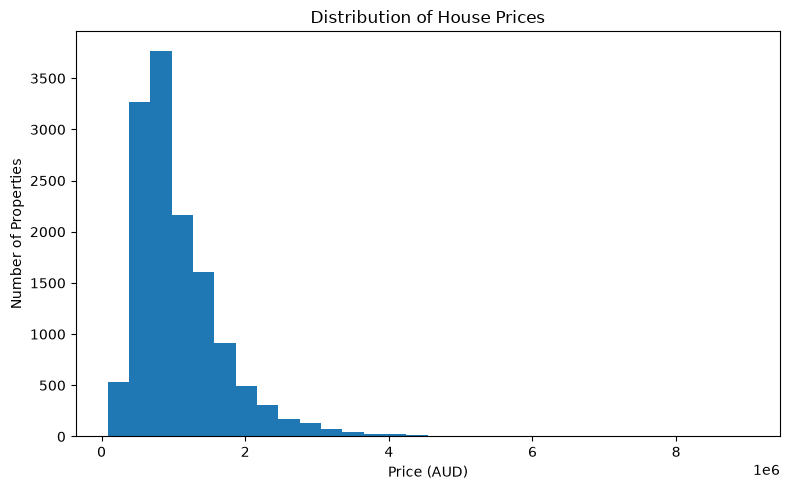

In [13]:
# TODO: Build a chart that shows the distribution of Price

fig, ax = plt.subplots(figsize=(8, 5))

# TODO: fill in the correct plotting call
ax.hist(df["Price"].dropna(), bins=30)

ax.set_xlabel("Price (AUD)")
ax.set_ylabel("Number of Properties")
ax.set_title("Distribution of House Prices")
plt.tight_layout()
plt.show()


## Part 3 — Image Formats & Compression (4 min)

Recall:
- **Bitmap** (PNG, JPEG) = pixels, fixed resolution. **Vector** (SVG, PDF) = shapes, resolution-independent.
- **Lossless** (PNG, TIFF) = no data removed. **Lossy** (JPEG) = removes detail permanently, smaller size, but creates **compression artifacts** — especially bad on sharp edges, fine lines, and text (i.e. **charts**).

Let's prove it. Save your region bar chart from Part 2.1 as **both** PNG and JPEG, and compare.


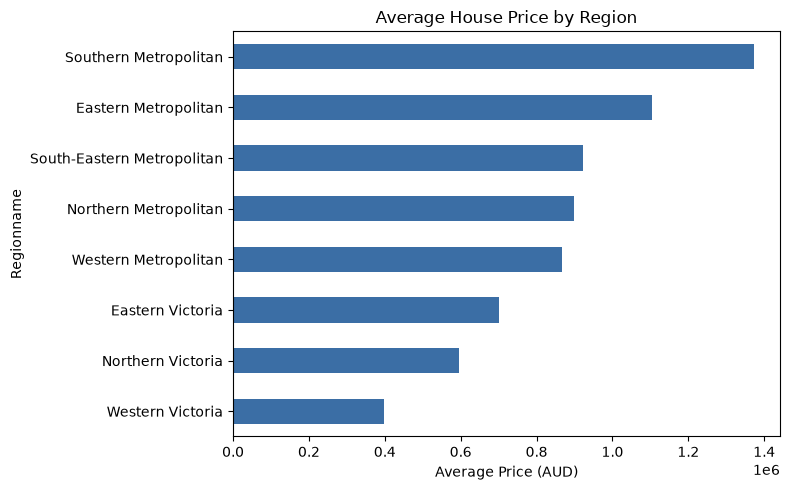

PNG size: 50.9 KB
JPEG size: 65.1 KB


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
region_avg.plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region")
plt.tight_layout()

# TODO: save the SAME figure in both formats
fig.savefig("region_chart.png", dpi=150)   # fill in: png
fig.savefig("region_chart.jpg", dpi=150)   # fill in: jpg
plt.show()

png_size = os.path.getsize("region_chart.png")
jpg_size = os.path.getsize("region_chart.jpg")
print(f"PNG size: {png_size/1024:.1f} KB")
print(f"JPEG size: {jpg_size/1024:.1f} KB")


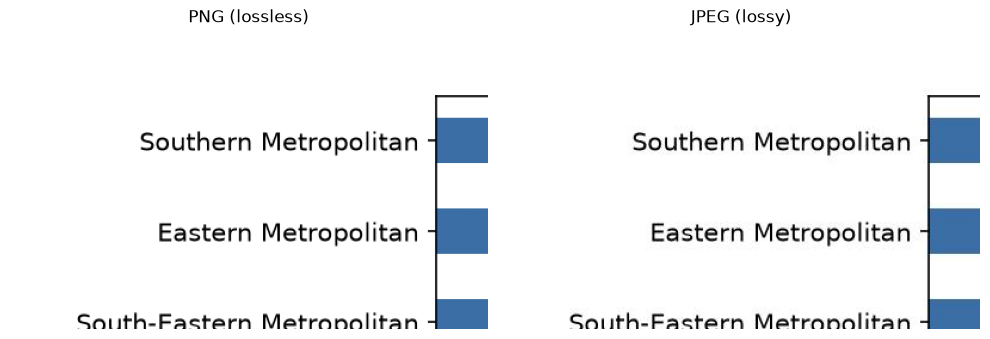

In [15]:
# Zoom into a saved image to inspect for compression artifacts around the text/edges
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, fname, label in zip(axes, ["region_chart.png", "region_chart.jpg"], ["PNG (lossless)", "JPEG (lossy)"]):
    img = Image.open(fname)
    w, h = img.size
    crop = img.crop((0, 0, w // 3, h // 3))  # zoom into top-left corner (title/text area)
    ax.imshow(crop)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()


### ✍️ Your turn

1. Which file was larger — PNG or JPEG? Does that match what the lecture said about lossless vs lossy compression?
2. Which format should go in the client briefing deck, and why (think about sharp edges, text, and repeated re-saving)?

**Your answers:**

1.JPEG was likely smaller than PNG because JPEG uses lossy compression, while PNG uses lossless compression. JPEG reduces file size by removing some image information, which generally results in smaller files.
2.PNG would be more suitable for the client briefing deck because its lossless compression preserves sharp text, lines, and chart details without introducing noticeable compression artifacts. It is also a better choice when images may be edited or re-saved multiple times.


## Part 4 — Separating Content from Design (3 min)

> *"Changing a theme should not change the data."*

**Content** = data, variables, axes, plot type. **Design** = colors, fonts, gridlines, theme, labels.

Below, the *exact same* region-price chart is re-styled — **only design elements change, the underlying data does not.**


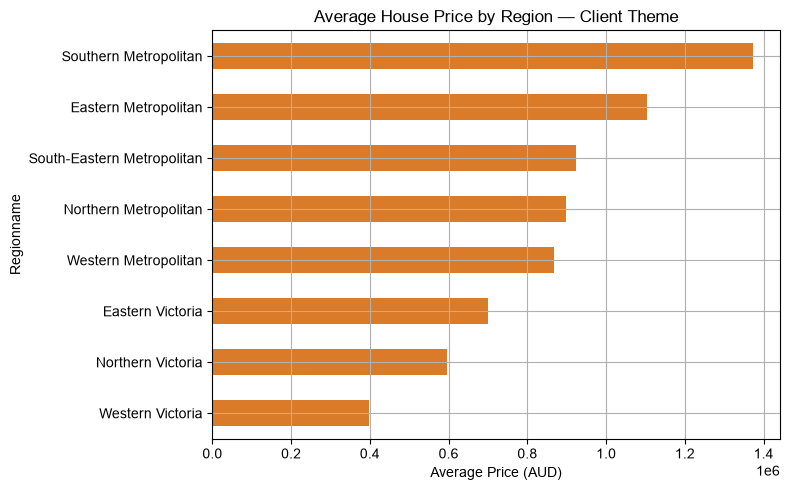

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
plt.style.use("seaborn-v0_8-darkgrid" if "seaborn-v0_8-darkgrid" in plt.style.available else "ggplot")

# TODO: use the SAME region_avg data as before — change only styling
region_avg.plot(kind="barh", ax=ax, color="#d97b29")

ax.set_xlabel("Average Price (AUD)")
ax.set_title("Average House Price by Region — Client Theme")
plt.tight_layout()
plt.show()

plt.style.use("default")  # reset


### ✍️ Your turn

Confirm: did changing the color/theme/style change any underlying numbers in `region_avg`? *(It shouldn't have.)* Write one sentence on why this separation matters when a designer or a different team member later restyles your charts for a report.

**Your answer:No, changing the colour, theme, or overall style did not affect any of the underlying values in region_avg. This separation is important because designers or other team members can modify the appearance of a chart without accidentally changing the underlying data or analysis.**


## Part 5 — The Big Idea (2 min, wrap-up)

Recall the lecture's **3-Minute Story** and **Big Idea** techniques:

> *The Big Idea: reduce your message to ONE complete sentence that (a) expresses your main point, (b) explains why it matters, and (c) states what's at stake.*

### ✍️ Final task

Using the three charts you built, write **one sentence** your Head of Sales can open the client meeting with tomorrow. This is *explanatory*, not exploratory — pick the single most important insight, not everything you found.

**Your Big Idea:Property prices differ significantly across Melbourne’s regions, making location a key factor in identifying the most promising property investment opportunities.**

> _______________________________________________________________________

---

### ✅ Quick self-check
1. Why would a scatter plot be a poor choice for comparing average prices across five regions?
*A scatter plot is not ideal because it is mainly used to show relationships between numerical variables. Since regions are categorical, a bar chart makes it much easier to compare their average prices.*

2. Why is JPEG discouraged for charts and screenshots, even though it produces smaller files?
*JPEG is discouraged because its lossy compression can create visible artifacts around text, sharp edges, and fine lines, which can reduce the clarity and readability of charts and screenshots.*

3. Name one thing that counts as "design" (not "content") in a chart.
*One example of a design element is the colour scheme used in the chart.*

